
**Comentario del Revisor**

Hola!

Soy Juan Manuel Romero, pero siéntete libre de llamarme Juanma. Soy code reviewer en Tripleten y hoy estaré revisando tu entrega.

Para simular la dinámica de un ambiente de trabajo, si veo algún error, en primer instancia solo los señalaré, dándote la oportunidad de encontrarlos y corregirlos por tu cuenta. En un trabajo real, el líder de tu equipo hará una dinámica similar. En caso de que no puedas resolver la tarea, te daré una información más precisa en la próxima revisión.

Solo un aviso rápido: cuando estés revisando el proyecto, por favor deja mis comentarios originales tal como están. De esta manera, podemos seguir fácilmente el progreso y asegurarnos de que no se nos pase nada por alto. Y, si realizas algún cambio basado en mis comentarios, sería genial si pudieras resaltar esas actualizaciones para que se destaquen.

Puedes encontrar mis comentarios en cajas verdes, amarillas o rojas como estas:

<div class="alert alert-block alert-success">
<b>Comentario del Revisor</b> <a class="tocSkip"></a>

Éxito. Todo se ha hecho correctamente.

</div>


<div class="alert alert-block alert-warning">
<b>Comentario del Revisor</b> <a class="tocSkip"></a>

Observaciones. Algunas recomendaciones.

</div>


<div class="alert alert-block alert-danger">
<b>Comentario del Revisor</b> <a class="tocSkip"></a>

Requiere corrección. El bloque requiere algunas correcciones. El trabajo no puede ser aceptado con los comentarios en rojo.

</div>

Puedes responderme usando esto:

<div class="alert alert-block alert-info"> <b>Respuesta del estudiante.</b> <a class="tocSkip"></a> </div>


<div class="alert alert-block alert-success">
<b>COMENTARIO GENERAL #1</b> <a class="tocSkip"></a>

Felicidades Alexis! Tu trabajo es muy bueno.

Has completado todos los items necesarios para aprobar la entrega. Sigue así!

</div>

In [ ]:
#Paso 1. Abre el archivo de datos y estudia la información general
import seaborn as sns
import numpy as np
import pandas as pd
from scipy import stats as st
from matplotlib import pyplot as plt

In [ ]:
df= pd.read_csv("/datasets/games.csv")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [ ]:
#Paso 2. Prepara los datos
#REEMPLAZO DE LOS NOMBRES EN MINUSCULA
df_lower=[]
for old_name in df:
    name_lowered=old_name.lower()
    df_lower.append(name_lowered)

df.columns=df_lower
print(df_lower)

['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales', 'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating']


<div class="alert alert-block alert-success">
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Se ha realizado el ajuste en el nombre de las columnas de forma correcta.

</div>

In [ ]:
df[df['name'].isna()]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
659,NaN,GEN,1993.0,NaN,1.78,0.53,0.00,0.08,NaN,NaN,NaN
14244,NaN,GEN,1993.0,NaN,0.00,0.00,0.03,0.00,NaN,NaN,NaN


In [ ]:
#CONVERSION DE VALORES AUSENTES
df["name"]=df["name"].fillna("Unknow")
df.isna().sum()

name                  0
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         6701
rating             6766
dtype: int64

In [ ]:
df[df["year_of_release"].isna()]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
183,Madden NFL 2004,PS2,NaN,Sports,4.26,0.26,0.01,0.71,94.0,8.5,E
377,FIFA Soccer 2004,PS2,NaN,Sports,0.59,2.36,0.04,0.51,84.0,6.4,E
456,LEGO Batman: The Videogame,Wii,NaN,Action,1.80,0.97,0.00,0.29,74.0,7.9,E10+
475,wwe Smackdown vs. Raw 2006,PS2,NaN,Fighting,1.57,1.02,0.00,0.41,NaN,NaN,NaN
609,Space Invaders,2600,NaN,Shooter,2.36,0.14,0.00,0.03,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16373,PDC World Championship Darts 2008,PSP,NaN,Sports,0.01,0.00,0.00,0.00,43.0,tbd,E10+
16405,Freaky Flyers,GC,NaN,Racing,0.01,0.00,0.00,0.00,69.0,6.5,T
16448,Inversion,PC,NaN,Shooter,0.01,0.00,0.00,0.00,59.0,6.7,M
16458,Hakuouki: Shinsengumi Kitan,PS3,NaN,Adventure,0.01,0.00,0.00,0.00,NaN,NaN,NaN


In [ ]:
#CONVERSION DE DATOS
df["year_of_release"]=df["year_of_release"].fillna(2000)
df["year_of_release"]=df["year_of_release"].astype(int)
print(df["year_of_release"].isna().sum())

0


<div class="alert alert-block alert-warning">
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Cuidado! Reemplazar todos los faltantes con un único valor no siempre es correcto. En caso de hacerlo, hay que tener cuidado con el valor que se utiliza.
    
Lo importante es que esté siempre bien justificado. Por qué crees que tal reemplazo es apropiado?

</div>

In [ ]:
df[df["genre"].isna()]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
659,Unknow,GEN,1993,NaN,1.78,0.53,0.00,0.08,NaN,NaN,NaN
14244,Unknow,GEN,1993,NaN,0.00,0.00,0.03,0.00,NaN,NaN,NaN


In [ ]:
#CONVERSION DE VALORES AUSENTES
df["genre"]=df["genre"].fillna("Unknow")
print(df["genre"].isna().sum())

0


In [ ]:
df[df["critic_score"].isna()]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
5,Tetris,GB,1989,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,NaN
9,Duck Hunt,NES,1984,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,NaN
10,Nintendogs,DS,2005,Simulation,9.05,10.95,1.93,2.74,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16711,LMA Manager 2007,X360,2006,Sports,0.00,0.01,0.00,0.00,NaN,NaN,NaN
16712,Haitaka no Psychedelica,PSV,2016,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16713,Spirits & Spells,GBA,2003,Platform,0.01,0.00,0.00,0.00,NaN,NaN,NaN


In [ ]:
#CONVERSION DE VALORES AUSENTES
df["critic_score"]=df["critic_score"].fillna(0.0)

In [ ]:
df[df["user_score"].isna()]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,0.0,NaN,NaN
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,0.0,NaN,NaN
5,Tetris,GB,1989,Puzzle,23.20,2.26,4.22,0.58,0.0,NaN,NaN
9,Duck Hunt,NES,1984,Shooter,26.93,0.63,0.28,0.47,0.0,NaN,NaN
10,Nintendogs,DS,2005,Simulation,9.05,10.95,1.93,2.74,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016,Action,0.00,0.00,0.01,0.00,0.0,NaN,NaN
16711,LMA Manager 2007,X360,2006,Sports,0.00,0.01,0.00,0.00,0.0,NaN,NaN
16712,Haitaka no Psychedelica,PSV,2016,Adventure,0.00,0.00,0.01,0.00,0.0,NaN,NaN
16713,Spirits & Spells,GBA,2003,Platform,0.01,0.00,0.00,0.00,0.0,NaN,NaN


In [ ]:
#CONVERSION DE VALORES AUSENTES Y REEMPLAZO DE "TBD"
df["user_score"]=df["user_score"].fillna(0.0)
df["user_score"]=df["user_score"].replace("tbd",0.0)

In [ ]:
df["user_score"]=df["user_score"].astype(float)

In [ ]:
print(df["user_score"].isna().sum())

0


In [ ]:
df[df["rating"].isna()]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,0.0,0.0,NaN
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,0.0,0.0,NaN
5,Tetris,GB,1989,Puzzle,23.20,2.26,4.22,0.58,0.0,0.0,NaN
9,Duck Hunt,NES,1984,Shooter,26.93,0.63,0.28,0.47,0.0,0.0,NaN
10,Nintendogs,DS,2005,Simulation,9.05,10.95,1.93,2.74,0.0,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016,Action,0.00,0.00,0.01,0.00,0.0,0.0,NaN
16711,LMA Manager 2007,X360,2006,Sports,0.00,0.01,0.00,0.00,0.0,0.0,NaN
16712,Haitaka no Psychedelica,PSV,2016,Adventure,0.00,0.00,0.01,0.00,0.0,0.0,NaN
16713,Spirits & Spells,GBA,2003,Platform,0.01,0.00,0.00,0.00,0.0,0.0,NaN


In [ ]:
#CONVERSION DE VALORES AUSENTES
df["rating"]=df["rating"].fillna("Unknow")

<div class="alert alert-block alert-warning">
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Aunque tienes un muy buen trabajo, nota que soluciones válidas en este caso para manejar los nulos serían:

- Introducir un valor irreal que depende de la columna y su significado (-1, -999999, etc.).
- Dejar los huecos sin cambios.

Los valores de Year_of_release se pueden cambiar a cero o eliminarse. Por su parte, no hay mucho que se puede hacer con los valores nulos de critic_score y user_score, los cuales se pueden dejar a null.

</div>

In [ ]:
#Explica por qué rellenaste los valores ausentes como lo hiciste o por qué decidiste dejarlos en blanco.
#R=Las columnas en las que los datos han sido modificados se debe a que interfieren en los analisis posteriores de los datos.
#¿Por qué crees que los valores están ausentes?
#R=Se podria deber a que no se llenaron los campos correspondientes.
#Presta atención a la abreviatura TBD: significa "to be determined" (a determinar). Especifica cómo piensas manejar estos casos.
#R=Se convirtio el dato a tipo numerico para que asi no interfiera con los analisis posteriores.

<div class="alert alert-block alert-warning">
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Recuerda utilizar celdas de texto para dejar tus comentarios y conclusiones ;)

</div>

In [ ]:
#VENTAS TOTALES
df["total_sales"]=df["na_sales"]+df["eu_sales"]+df["jp_sales"]+df["other_sales"]
print(df)

                                name platform  year_of_release         genre  \
0                         Wii Sports      Wii             2006        Sports   
1                  Super Mario Bros.      NES             1985      Platform   
2                     Mario Kart Wii      Wii             2008        Racing   
3                  Wii Sports Resort      Wii             2009        Sports   
4           Pokemon Red/Pokemon Blue       GB             1996  Role-Playing   
...                              ...      ...              ...           ...   
16710  Samurai Warriors: Sanada Maru      PS3             2016        Action   
16711               LMA Manager 2007     X360             2006        Sports   
16712        Haitaka no Psychedelica      PSV             2016     Adventure   
16713               Spirits & Spells      GBA             2003      Platform   
16714            Winning Post 8 2016      PSV             2016    Simulation   

       na_sales  eu_sales  jp_sales  ot

<div class="alert alert-block alert-success">
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Muy buen trabajo calculando las ventas totales.

<div class="alert alert-block alert-warning">
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Otra forma de hacerlo es de la siguiente manera:

	data['total_sales']=data[['na_sales','eu_sales','jp_sales','other_sales']].sum(axis=1)

</div>

</div>

In [ ]:
#Paso 3. Analiza los datos
platform_for_years = df.groupby("year_of_release")["name"].count()
platform_for_years.reset_index()

,year_of_release,name
0,1980,9
1,1981,46
2,1982,36
3,1983,17
4,1984,14
5,1985,14
6,1986,21
7,1987,16
8,1988,15
9,1989,17


<div class="alert alert-block alert-success">
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Muy buen análisis sobre el lanzamiento de los videojuegos.
<div class="alert alert-block alert-warning">
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Sin embargo, podrías utilizar un gráfico para que se pueda entender fácilmente tu análisis.

</div>

</div>

In [ ]:
platform_for_years.describe()

count      37.000000
mean      451.756757
std       452.158736
min         9.000000
25%        36.000000
50%       338.000000
75%       762.000000
max      1427.000000
Name: name, dtype: float64

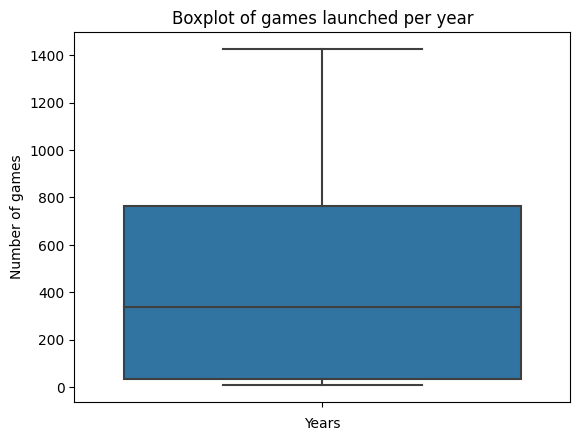

In [ ]:
sns.boxplot(y=platform_for_years)
plt.title("Boxplot of games launched per year")
plt.xlabel("Years")
plt.ylabel("Number of games")
plt.show()

<div class="alert alert-block alert-warning">
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

 Si quieres visualizar cuántos juegos se lanzaron por año, una mejor opción sería usar sns.countplot(x=years) o un gráfico de barras agregando los datos por año con groupby.

</div>


In [ ]:
#Mira cuántos juegos fueron lanzados en diferentes años. ¿Son significativos los datos de cada período?
#R= Se podria decir que si son significativos los juegos lanzados en diferentes años, dado que el lanzamiento de los juegos
#ha sido de forma ascendente desde el primer año de lanzamiento hasta el 2008 que es cuando llega a su maximo valor y teniendo una gran amplitud en los datos por cuartiles

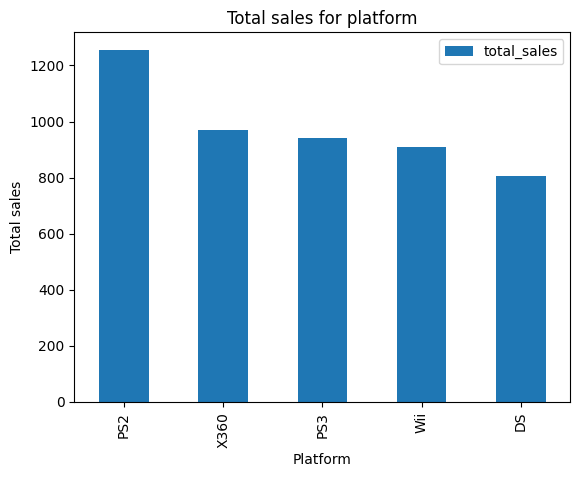

In [ ]:
#PLATAFORMAS CON MAYORES VENTAS
platform_sales = df.groupby("platform")["total_sales"].sum()
platform_sales_ascending=platform_sales.sort_values(ascending=False)
platform_sales_ascending=platform_sales_ascending.reset_index().head()
platform_sales_ascending.plot(x='platform',
        y="total_sales",
        kind='bar',
        title='Total sales for platform',
        xlabel='Platform',
        ylabel='Total sales')
plt.show()
#Plataformas con mayores ventas totales = PS2, X360, PS3, Wii, DS
#Estas 5 plataformas son las que son lideres en ventas.

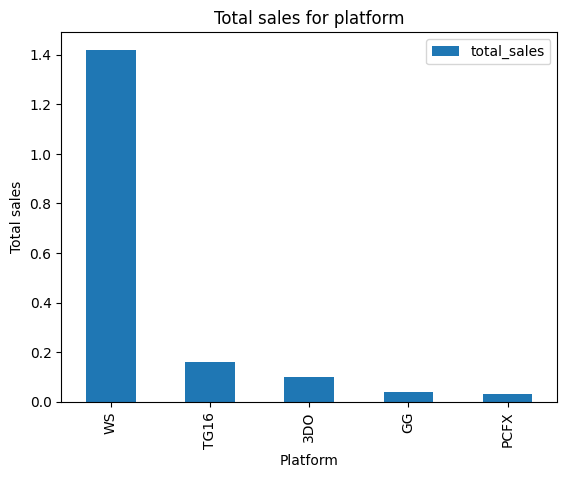

In [ ]:
platform_sales_ascending_tail=platform_sales.sort_values(ascending=False)
platform_sales_ascending_tail=platform_sales_ascending_tail.reset_index().tail()
platform_sales_ascending_tail.plot(x='platform',
        y="total_sales",
        kind='bar',
        title='Total sales for platform',
        xlabel='Platform',
        ylabel='Total sales')
plt.show()
#Plataformas con menores ventas totales = WS, TG16, 3DO, GG, PCFX
#Estas plataformas son las que se reducen en ventas.

In [ ]:
#PLATAFORMAS MENOS POPULARES
platform_years_ascending_ws=df[df["platform"]=="WS"]["year_of_release"].reset_index().dropna()
platform_years_ascending_ws=platform_years_ascending_ws.sort_values(by="year_of_release",ascending=False)
platform_years_ws_mean=platform_years_ascending_ws["year_of_release"].mean()
"Year mean",platform_years_ws_mean

('Year mean', 2000.0)

In [ ]:
platform_years_ascending_TG16=df[df["platform"]=="TG16"]["year_of_release"].reset_index().dropna()
platform_years_ascending_TG16=platform_years_ascending_TG16.sort_values(by="year_of_release",ascending=False)
platform_years_TG16_mean=platform_years_ascending_TG16["year_of_release"].mean()
"Year mean",platform_years_TG16_mean

('Year mean', 1995.0)

In [ ]:
platform_years_ascending_3DO=df[df["platform"]=="3DO"]["year_of_release"].reset_index().dropna()
platform_years_ascending_3DO=platform_years_ascending_3DO.sort_values(by="year_of_release",ascending=False)
platform_years_3DO_mean=platform_years_ascending_3DO["year_of_release"].mean()
"Year mean",platform_years_3DO_mean

('Year mean', 1994.6666666666667)

In [ ]:
platform_years_ascending_GG=df[df["platform"]=="GG"]["year_of_release"].reset_index().dropna()
platform_years_ascending_GG=platform_years_ascending_GG.sort_values(by="year_of_release",ascending=False)
platform_years_GG_mean=platform_years_ascending_GG["year_of_release"].mean()
"Year mean",platform_years_GG_mean

('Year mean', 1992.0)

In [ ]:
platform_years_ascending_PCFX=df[df["platform"]=="PCFX"]["year_of_release"].reset_index().dropna()
platform_years_ascending_PCFX=platform_years_ascending_PCFX.sort_values(by="year_of_release",ascending=False)
platform_years_PCFX_mean=platform_years_ascending_PCFX["year_of_release"].mean()
"Year mean",platform_years_PCFX_mean

('Year mean', 1996.0)

In [ ]:
#PLATAFORMAS MAS POPULARES
platform_years_ascending_PS2=df[df["platform"]=="PS2"]["year_of_release"].reset_index().dropna()
platform_years_ascending_PS2=platform_years_ascending_PS2.sort_values(by="year_of_release",ascending=False)
"Year mean",platform_years_ascending_PS2["year_of_release"].mean()

('Year mean', 2004.5118000925497)

In [ ]:
platform_years_ascending_X360=df[df["platform"]=="X360"]["year_of_release"].reset_index().dropna()
platform_years_ascending_X360=platform_years_ascending_X360.sort_values(by="year_of_release",ascending=False)
"Year mean",platform_years_ascending_X360["year_of_release"].mean()

('Year mean', 2009.6458003169573)

In [ ]:

platform_years_ascending_PS3=df[df["platform"]=="PS3"]["year_of_release"].reset_index().dropna()
platform_years_ascending_PS3=platform_years_ascending_PS3.sort_values(by="year_of_release",ascending=False)
"Year mean",platform_years_ascending_PS3["year_of_release"].mean()

('Year mean', 2010.6371149511644)

In [ ]:
platform_years_ascending_Wii=df[df["platform"]=="Wii"]["year_of_release"].reset_index().dropna()
platform_years_ascending_Wii=platform_years_ascending_Wii.sort_values(by="year_of_release",ascending=False)
"Year mean",platform_years_ascending_Wii["year_of_release"].mean()

('Year mean', 2008.735606060606)

In [ ]:
platform_years_ascending_DS=df[df["platform"]=="DS"]["year_of_release"].reset_index().dropna()
platform_years_ascending_DS=platform_years_ascending_DS.sort_values(by="year_of_release",ascending=False)
"Year mean",platform_years_ascending_DS["year_of_release"].mean()

('Year mean', 2008.071129707113)

<div class="alert alert-block alert-warning">
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Nota que aquí tienes bastante código que se repite celda tras celda. Luego, puedes crear un método con el código repetido para poder reutilizar el mismo.

Además, al hacer reset_index() sin drop=True, mantienes la columna del índice antiguo, que puede ser innecesaria.

Por otro lado, no queda claro el valor que aporta. Podrías dejar conclusiones y comentarios para explicar el objetivo de tus análisis y los resultados que obtienes.

</div>

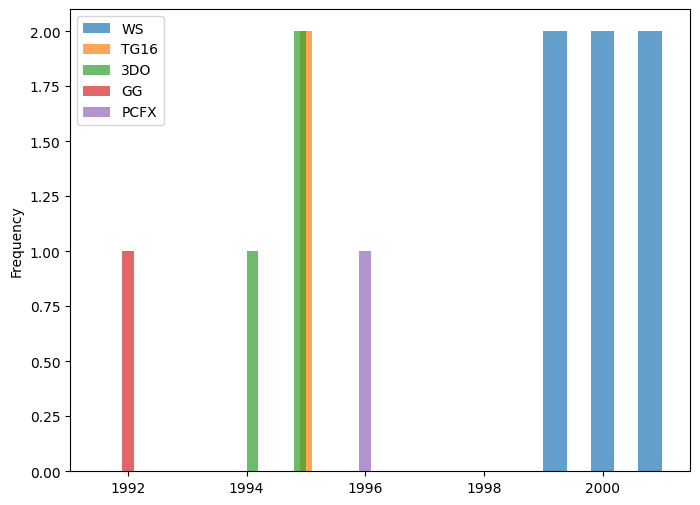

In [ ]:
df[df['platform'] == "WS"]['year_of_release'].plot(kind='hist', bins=5, alpha= 0.7, figsize= [8,6])
df[df['platform'] == "TG16"]['year_of_release'].plot(kind='hist', bins=5, alpha= 0.7, figsize= [8,6])
df[df['platform'] == "3DO"]['year_of_release'].plot(kind='hist', bins=5, alpha= 0.7, figsize= [8,6])
df[df['platform'] == "GG"]['year_of_release'].plot(kind='hist', bins=5, alpha= 0.7, figsize= [8,6])
df[df['platform'] == "PCFX"]['year_of_release'].plot(kind='hist', bins=5, alpha= 0.7, figsize= [8,6])
plt.legend(["WS","TG16","3DO", "GG", "PCFX"])
plt.show()
# ¿Cuánto tardan generalmente las nuevas plataformas en aparecer y las antiguas en desaparecer?
# Del siguiente histograma se pueden visualizar las 5 plataformas que tienen menor numero de ventas y el numero de años de lanzamiento de los juegos,
# en donde se puede apreciar que la plataforma "WS" tiene el mayor numero de años de lanzamiento cerca de los 2000.
# La plataforma "GG" tiene el menor numero de años de lanzamiento con 1992, las otras 3 estan en el medio.

<div class="alert alert-block alert-warning">
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

La visualización es válida para comparar distribuciones, pero usar múltiples .plot() separados genera varios histogramas superpuestos sin control claro sobre colores ni ejes consistentes. Es preferible combinar los datos y usar sns.histplot() con hue='platform' para mayor claridad. Además, en el análisis textual hay confusión: no se trata de cuántos años tuvo lanzamientos, sino en qué años ocurrieron. Mejor enfocar el análisis en el rango de años activos por plataforma (año mínimo y máximo) y calcular su duración.

</div>

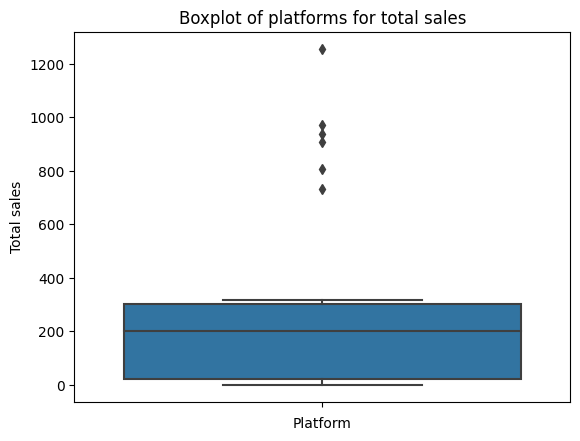

In [ ]:
#DIAGRAMA DE CAJA PARA LAS VENTAS GLOBALES
sns.boxplot(y=platform_sales)
plt.title("Boxplot of platforms for total sales")
plt.xlabel("Platform")
plt.ylabel("Total sales")
plt.show()

<div class="alert alert-block alert-warning">
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

El código intenta hacer un boxplot de ventas globales por plataforma, pero al pasar solo y=platform_sales, falta una variable categórica en el eje x para que el boxplot agrupe por plataforma. Deberías usar sns.boxplot(x='platform', y='global_sales', data=df) para que funcione correctamente. Así obtendrás una visualización válida de la distribución de ventas por plataforma.

Además, podrías profundizar mucho más tu análisis.

Un **boxplot** (o diagrama de caja y bigotes) es una herramienta gráfica que permite visualizar la distribución de un conjunto de datos de manera eficiente. Sus principales beneficios son:

1. **Resumir la distribución de los datos** → Muestra la mediana, cuartiles y valores extremos de un conjunto de datos de forma compacta.
2. **Detectar outliers fácilmente** → Los valores atípicos quedan representados fuera de los "bigotes", facilitando su identificación.
3. **Comparar distribuciones** → Útil para analizar cómo varían los datos entre diferentes categorías o grupos.
4. **Mostrar asimetría y dispersión** → Permite observar si los datos están sesgados y qué tan dispersos están.
5. **Resistencia a valores extremos** → No se ve tan afectado por outliers como otras visualizaciones, como histogramas o medias.


</div>

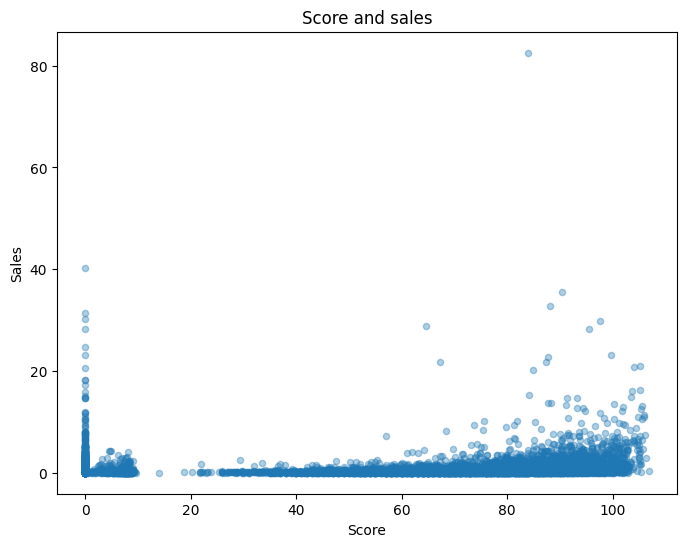

In [ ]:
#RESEÑAS DE LOS USUARIOS Y PROFESIONALES
df["total_score"]=df['user_score']+df["critic_score"]
df.plot(x="total_score", y='total_sales', kind='scatter', title="Score and sales",  alpha= 0.36, figsize= [8,6], xlabel="Score", ylabel="Sales")
plt.show()

<div class="alert alert-block alert-warning">
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Aunque vas muy bien, aun el proceso no es del todo correcto. Realmente deberías ver que hay una correlación positiva para las reseñas de los críticos y que no sucede lo mismo con el puntaje de los usuarios.  Es decir, debes ver que un puntaje más alto de los críticos generalmente trae más ingresos.

</div>

In [ ]:
print(df["total_score"].corr(df['total_sales']))
#Se puede concluir que no existe una correlación tan fuerte entre las reseñas de los ususarios y el numero de ventas totales.

0.14981309446433244


<div class="alert alert-block alert-warning">
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Te recomiendo usar celdas de tipo **Markdown** para organizar mejor tu trabajo. Puedes agregar **títulos**, separar secciones y explicar tu código de manera clara. Esto no solo mejora la legibilidad, sino que también te ayuda a entender y explicar mejor tu proceso. 📚✍️

</div>

In [ ]:
#Paso 4. Crea un perfil de usuario para cada región
region_na= df.groupby("platform")["na_sales"].sum()
region_ascending_na=region_na.sort_values(ascending=False)
region_ascending_head_na=region_ascending_na.head()
region_ascending_head_na

platform
X360    602.47
PS2     583.84
Wii     496.90
PS3     393.49
DS      382.40
Name: na_sales, dtype: float64

In [ ]:
region_eu=df.groupby("platform")["eu_sales"].sum()
region_ascending_eu=region_eu.sort_values(ascending=False)
region_ascending_head_eu=region_ascending_eu.head()
region_ascending_head_eu

platform
PS2     339.29
PS3     330.29
X360    270.76
Wii     262.21
PS      213.61
Name: eu_sales, dtype: float64

In [ ]:
region_jp=df.groupby("platform")["jp_sales"].sum()
region_ascending_jp=region_jp.sort_values(ascending=False)
region_ascending_head_jp=region_ascending_jp.head()
region_ascending_head_jp

platform
DS      175.57
PS      139.82
PS2     139.20
SNES    116.55
3DS     100.67
Name: jp_sales, dtype: float64

<div class="alert alert-block alert-warning">
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Al analizar plataformas y géneros, todo lo que no esté incluido en el TOP-5 podría combinarse en "otros", para que la imagen del análisis sea más completa.

</div>

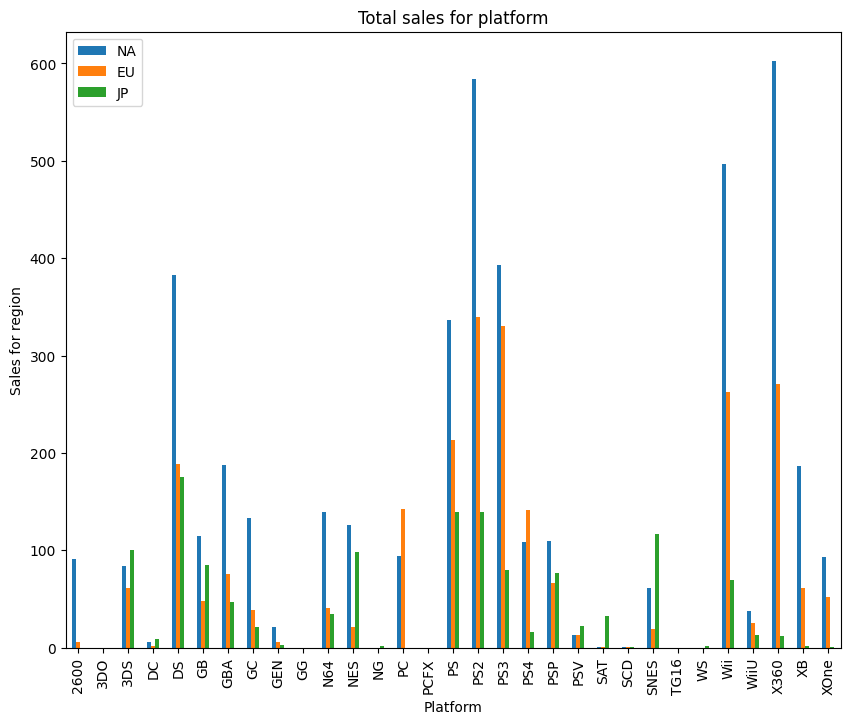

In [ ]:
#Las cinco plataformas principales. Describe las variaciones en sus cuotas de mercado de una región a otra.
region_total_platform=df.groupby("platform")["na_sales","eu_sales","jp_sales"].sum()

region_total_platform.plot(
        figsize=(10, 8),
        kind='bar',
        title='Total sales for platform',
        xlabel='Platform', ylabel='Sales for region')
plt.legend(['NA', 'EU', "JP"])
plt.show()

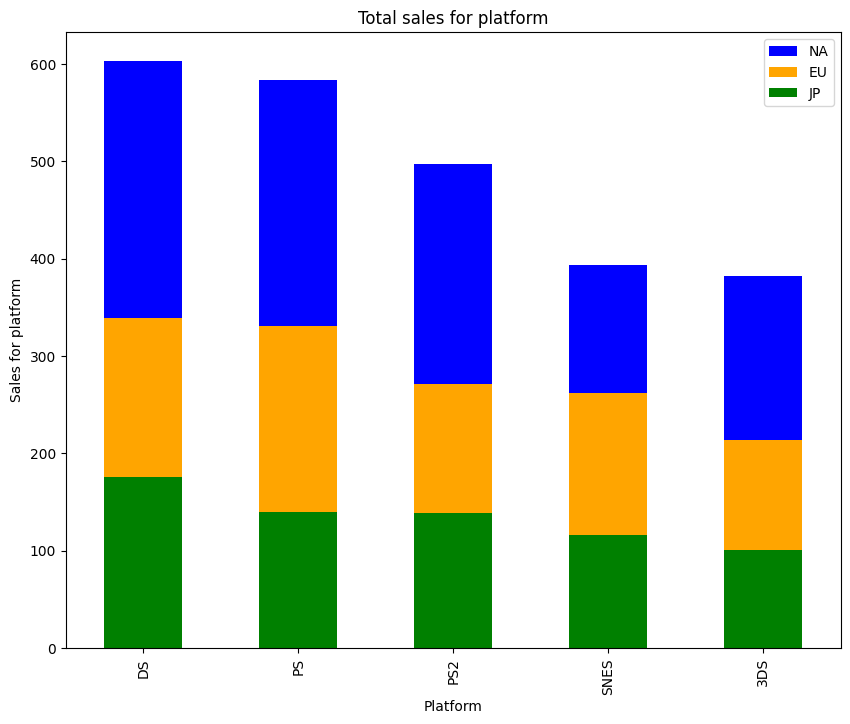

In [ ]:
region_ascending_head_na.plot(x="platform", y="na_sales",
        figsize=(10, 8),
        kind='bar',
        title='Total sales for platform',
        xlabel='Platform', ylabel='Sales for platform',
        color="blue")
region_ascending_head_eu.plot(x="platform", y="eu_sales",
        figsize=(10, 8),
        kind='bar',
        title='Total sales for platform',
        xlabel='Platform', ylabel='Sales for platform',
        color="orange")
region_ascending_head_jp.plot(x="platform", y="jp_sales",
        figsize=(10, 8),
        kind='bar',
        title='Total sales for platform',
        xlabel='Platform', ylabel='Sales for platform',
        color="green")

plt.legend(['NA', 'EU', "JP"])
plt.show()
#En la siguiente grafica se aprecian las plataformas que tienen mayor presencia en las 3 regiones.
# La plataforma "DS" domina los 3 mercados en cuanto a las ventas que genera, la que menor ventas genera es "3DS".

In [ ]:
genre_na= df.groupby("genre")["na_sales"].sum()
genre_ascending_na=genre_na.sort_values(ascending=False)
genre_ascending_head_na=genre_ascending_na
genre_ascending_head_na=genre_ascending_head_na.head()

In [ ]:
genre_eu= df.groupby("genre")["eu_sales"].sum()
genre_ascending_eu=genre_eu.sort_values(ascending=False)
genre_ascending_head_eu=genre_ascending_eu
genre_ascending_head_eu=genre_ascending_head_eu.head()

In [ ]:
genre_jp= df.groupby("genre")["jp_sales"].sum()
genre_ascending_jp=genre_jp.sort_values(ascending=False)
genre_ascending_head_jp=genre_ascending_jp
genre_ascending_head_jp=genre_ascending_head_jp.head()

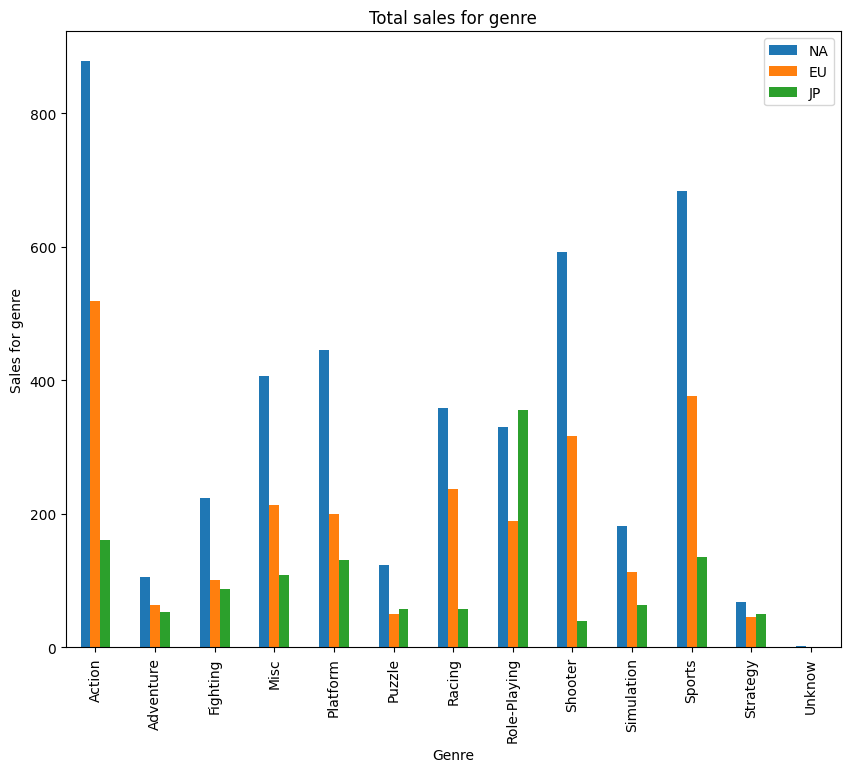

In [ ]:
#Los cinco géneros principales. Explica la diferencia.
region_total_genre=df.groupby("genre")["na_sales","eu_sales","jp_sales"].sum()

region_total_genre.plot(
        figsize=(10, 8),
        kind='bar',
        title='Total sales for genre',
        xlabel='Genre', ylabel='Sales for genre')
plt.legend(['NA', 'EU', "JP"])
plt.show()


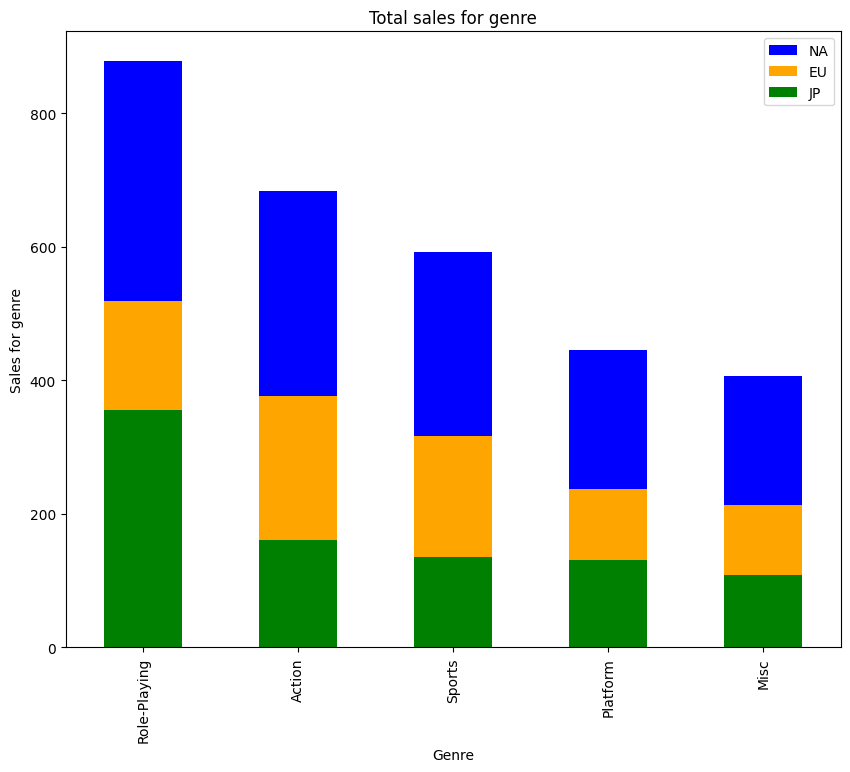

In [ ]:
genre_ascending_head_na.plot(x="genre", y="na_sales",
        figsize=(10, 8),
        kind='bar',
        title='Total sales for genre',
        xlabel='Genre', ylabel='Sales for genre',
        color="blue")
genre_ascending_head_eu.plot(x="genre", y="eu_sales",
        figsize=(10, 8),
        kind='bar',
        title='Total sales for genre',
        xlabel='Genre', ylabel='Sales for genre',
        color="orange")
genre_ascending_head_jp.plot(x="genre", y="jp_sales",
        figsize=(10, 8),
        kind='bar',
        title='Total sales for genre',
        xlabel='Genre', ylabel='Sales for genre',
        color="green")

plt.legend(['NA', 'EU', "JP"])
plt.show()
# La diferencia de los 5 generos principales por regiones se podria decir que el genero "Role-Playing" tiene la mayor cantidad de ventas en Japon, y norteamerica
# el genero "Action" domina en el mercado de norteamerica, seguido por europa, el genero "Sports" domina en norteamerica seguido de europa
# el genero "Platform" domina en norteamerica seguido de japon y el genero "Misc" domina en norteamerica seguido de japon.

<div class="alert alert-block alert-success">
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Todos los gráficos y conclusiones son correctos.

</div>

In [ ]:
rating_na= df.groupby("rating")["na_sales"].sum()
rating_ascending_na=rating_na.sort_values(ascending=False)
rating_ascending_head_na=rating_ascending_na.reset_index()
rating_ascending_head_na.head()

,rating,na_sales
0,E,1292.99
1,Unknow,1242.46
2,T,759.75
3,M,748.48
4,E10+,353.32


In [ ]:
rating_eu= df.groupby("rating")["eu_sales"].sum()
rating_ascending_eu=rating_eu.sort_values(ascending=False)
rating_ascending_head_eu=rating_ascending_eu.reset_index()
rating_ascending_head_eu.head()

,rating,eu_sales
0,E,710.25
1,Unknow,613.83
2,M,483.97
3,T,427.03
4,E10+,188.52


In [ ]:
rating_jp= df.groupby("rating")["jp_sales"].sum()
rating_ascending_jp=rating_jp.sort_values(ascending=False)
rating_ascending_head_jp=rating_ascending_jp.reset_index()
rating_ascending_head_jp.head()

,rating,jp_sales
0,Unknow,841.96
1,E,198.11
2,T,151.40
3,M,64.24
4,E10+,40.20


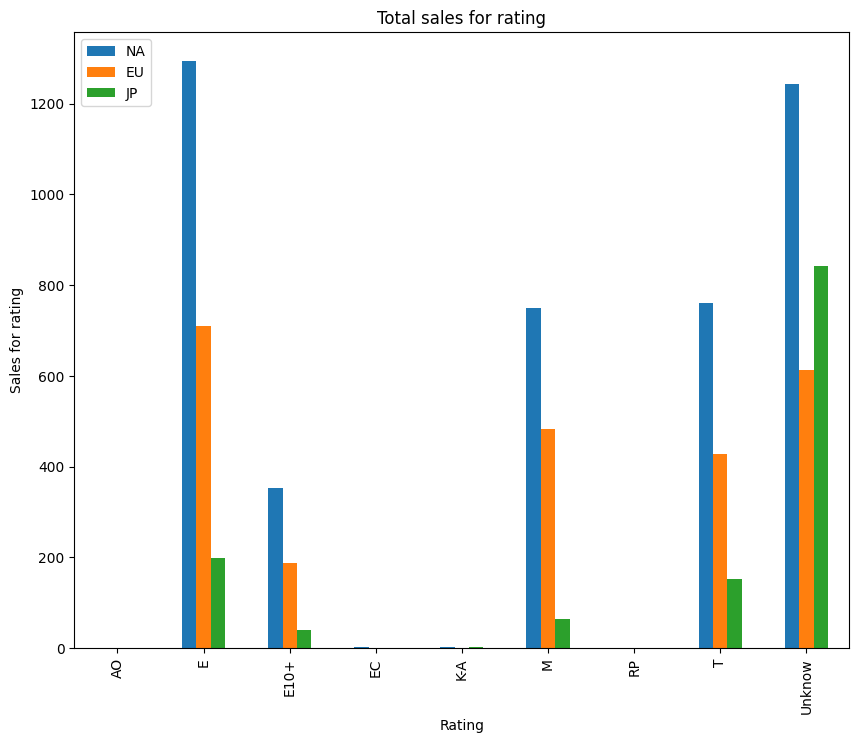

In [ ]:
#Si las clasificaciones de ESRB afectan a las ventas en regiones individuales.
region_total_rating=df.groupby("rating")["na_sales","eu_sales","jp_sales"].sum()

region_total_rating.plot(
        figsize=(10, 8),
        kind='bar',
        title='Total sales for rating',
        xlabel='Rating', ylabel='Sales for rating')
plt.legend(['NA', 'EU', "JP"])
plt.show()
# Se podria concluir que si, las clasificaciones de los juegos afecta al numero de ventas por region ya que la clasificaciòn "E" tiene
# el mayor numero de ventas en norteamerica y europa, seguida por la clasificacion "T" y "M", la clasificacion "E10+" tiene la menor cantidad de ventas
# la clasificacion "Unknow" representa muchas ventas, sin embargo se desconocen los generos que podrian ser.

<div class="alert alert-block alert-success">
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

El análisis realizado por cada región está muy bien fundamentado. Además, los resultados se presentan de forma clara y ordenada, lo que facilita la comprensión de la información. Esto permite identificar rápidamente las diferencias y similitudes entre cada región, y contribuye a un mejor entendimiento de los patrones generales.

<div class="alert alert-block alert-warning">
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Como sugerencia, podrías agregar una visualización comparativa (por ejemplo, un gráfico de barras apiladas o un heatmap) para reforzar visualmente los contrastes entre regiones en géneros o plataformas.

</div>

</div>

<div class="alert alert-block alert-success">
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Has definido correctamente las hipótesis.

</div>

In [ ]:
#Paso 5. Prueba las siguientes hipótesis:
#— Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son las mismas.
user_score_xone=df[df["platform"]=="XOne"]["user_score"].dropna()
user_score_pc=df[df["platform"]=="PC"]["user_score"].dropna()

alpha = 0.05
results = st.ttest_ind(user_score_xone, user_score_pc, equal_var=False)
print('valor p:', results.pvalue)

if (results.pvalue < alpha):
    print("Rechazamos la hipótesis nula")
else:
    print("No podemos rechazar la hipótesis nula")

#Las calificaciones promedio de los ususarios para las plataformas Xone y PC son significativamente diferentes.

valor p: 0.0005315801015576501
Rechazamos la hipótesis nula


<div class="alert alert-block alert-warning">
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a>

Al realizar una prueba de hipótesis, es muy importante verificar los supuestos. El t-test que usaste funciona bien cuando se cumplen ciertos supuestos, como que las varianzas de ambos grupos sean similares. Puedes realizar la prueba de levene para comprobar que los dos grupos tienen la misma varianza y, de esta forma, podrás saber el valor del parámetro equal_var que se debe utilizar en la función stats.ttest_ind.

</div>

In [ ]:
#— Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes.
total_score_sports=df[df["genre"]=="Sports"]["total_score"].dropna()
total_score_action=df[df["genre"]=="Action"]["total_score"].dropna()
alpha = 0.05

results = st.ttest_ind(total_score_sports, total_score_action, equal_var=False)
print('valor p:', results.pvalue)

if (results.pvalue < alpha):
    print("Rechazamos la hipótesis nula")
else:
    print("No podemos rechazar la hipótesis nula")

#Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes no son significativamente diferentes.

valor p: 0.20223367398514272
No podemos rechazar la hipótesis nula


<div class="alert alert-block alert-success">
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a><p>
Los resultados obtenidos son coherentes con lo esperado. Muy buen trabajo aplicando las pruebas de hipótesis!
</p>
<div class="alert alert-block alert-warning">
<b>Comentario del Revisor #1</b> <a class="tocSkip"></a><p>
He notado que hay fragmentos de código repetidos en ambos procesos. Sería recomendable encapsularlos en funciones para mejorar la reutilización y mantener un código más limpio y modular.
</p>
</div>
</div>

In [ ]:
#CONCLUSION
# Con los datos analizados en el presente DF se puede concluir que existen diferencias significativas entre las diferentes regiones y las ventas que estas tienen
# dado que la region "NA" representa la mayor cantidad de ventas a diferencia de las otras 2.
# Existen plataformas que son lideres en ventas siendo estas las mas actuales a diferencia de las plataformas que son mas antiguas.
# Los generos juegan un rol importante al momento de analizar cuales generan mayores ventas
# La region de "JP" es la que menor consumo de videojuegos tiene.